# Single-photon MC studies over a directory of FLOW files

This notebook follows the original single-file study, but aggregates the distributions over **all events found in all matching files** inside a user-provided directory.

Runtime-focused changes:
- discover files once with `Path.glob`
- read only the datasets needed for each plot
- use `np.bincount` for total segment energy per event
- use cumulative sums over charge-hit arrays instead of looping event-by-event
- concatenate arrays once at the end instead of repeatedly growing Python lists

In [36]:
from pathlib import Path
import os
import sys
import time

import h5py
import matplotlib.pyplot as plt
import numpy as np

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if repo_root not in sys.path:
    sys.path.append(repo_root)

plt.style.use('../../utils/dune.mplstyle')

In [37]:
# User configuration
flow_dir = Path("/pscratch/sd/l/lmlepin/grid_output/gammas_4.4_MeV_setA/FLOW")
file_pattern = "*.FLOW.hdf5"
max_files = None  # Set to an integer for a quick test run.

assert flow_dir.exists(), f"Directory does not exist: {flow_dir}"
print(f"Searching in: {flow_dir}")
print(f"Pattern: {file_pattern}")

Searching in: /pscratch/sd/l/lmlepin/grid_output/gammas_4.4_MeV_setA/FLOW
Pattern: *.FLOW.hdf5


In [38]:
def find_flow_files(directory, pattern="*.FLOW.hdf5", max_files=None):
    files = sorted(directory.glob(pattern))
    if max_files is not None:
        files = files[:max_files]
    return files


def _concat_or_empty(chunks, dtype=float):
    if not chunks:
        return np.array([], dtype=dtype)
    return np.concatenate(chunks)


def _region_bounds(ref_region):
    ref_region = np.asarray(ref_region)
    if len(ref_region) == 0:
        return np.array([], dtype=np.int64), np.array([], dtype=np.int64)

    if ref_region.dtype.names is not None:
        field0, field1 = ref_region.dtype.names[:2]
        return ref_region[field0].astype(np.int64), ref_region[field1].astype(np.int64)

    if ref_region.ndim == 2 and ref_region.shape[1] >= 2:
        return ref_region[:, 0].astype(np.int64), ref_region[:, 1].astype(np.int64)

    starts = np.empty(len(ref_region), dtype=np.int64)
    stops = np.empty(len(ref_region), dtype=np.int64)
    for i, region in enumerate(ref_region):
        region_arr = np.asarray(region).reshape(-1)
        if region_arr.size < 2:
            raise ValueError(f'Could not parse ref_region entry {i}: {region!r}')
        starts[i] = int(region_arr[0])
        stops[i] = int(region_arr[1])
    return starts, stops


def summarize_flow_file(file_path):
    summary = {
        "file": str(file_path),
        "electron_energy": np.array([], dtype=np.float32),
        "segment_dE": np.array([], dtype=np.float32),
        "total_edep": np.array([], dtype=np.float64),
        "total_n_electrons": np.array([], dtype=np.float64),
        "hit_energy": np.array([], dtype=np.float32),
        "hit_total_energy": np.array([], dtype=np.float64),
        "hit_total_energy_from_charge": np.array([], dtype=np.float64),
        "hit_total_charge": np.array([], dtype=np.float64),
        "hits_per_event": np.array([], dtype=np.int64),
        "n_zero_hit_events": 0,
        "n_charge_events": 0,
        "n_segment_events": 0,
    }

    with h5py.File(file_path, "r") as h5_file:
        trajectories = h5_file["mc_truth/trajectories/data"]
        segments = h5_file["mc_truth/segments/data"]

        electron_mask = trajectories["pdg_id"] == 11
        summary["electron_energy"] = trajectories[electron_mask]["E_start"] - 0.511

        segment_dE = segments["dE"]
        summary["segment_dE"] = segment_dE
        segment_n_electrons = segments["n_electrons"]

        event_ids, inverse = np.unique(segments["event_id"], return_inverse=True)
        summary["n_segment_events"] = len(event_ids)
        summary["total_edep"] = np.bincount(inverse, weights=segment_dE)
        summary["total_n_electrons"] = np.bincount(inverse, weights=segment_n_electrons)

        charge_hits = h5_file["charge/calib_prompt_hits/data"]
        ref_region = np.asarray(h5_file["charge/events/ref/charge/calib_prompt_hits/ref_region"])
        summary["n_charge_events"] = len(ref_region)

        if len(charge_hits) == 0 or len(ref_region) == 0:
            summary["n_zero_hit_events"] = len(ref_region)
            return summary

        starts, stops = _region_bounds(ref_region)
        counts = stops - starts
        nonzero_mask = counts > 0

        energy_all = charge_hits["E"]
        charge_all = charge_hits["Q"]
        summary["hit_energy"] = energy_all
        summary["n_zero_hit_events"] = int((~nonzero_mask).sum())
        summary["hits_per_event"] = counts[nonzero_mask]

        hit_energy_from_charge = (charge_all*1e3 * 23.6) / 0.58 /1e6
        cumsum_energy = np.concatenate(([0.0], np.cumsum(energy_all, dtype=np.float64)))
        cumsum_charge = np.concatenate(([0.0], np.cumsum(charge_all, dtype=np.float64)))
        cumsum_energy_from_charge = np.concatenate(([0.0], np.cumsum(hit_energy_from_charge, dtype=np.float64)))
        summary["hit_total_energy"] = cumsum_energy[stops[nonzero_mask]] - cumsum_energy[starts[nonzero_mask]]
        summary["hit_total_energy_from_charge"] = cumsum_energy_from_charge[stops[nonzero_mask]] - cumsum_energy_from_charge[starts[nonzero_mask]]
        summary["hit_total_charge"] = cumsum_charge[stops[nonzero_mask]] - cumsum_charge[starts[nonzero_mask]]

    return summary


def summarize_flow_directory(files):
    aggregate = {
        "electron_energy": [],
        "segment_dE": [],
        "total_edep": [],
        "total_n_electrons": [],
        "hit_energy": [],
        "hit_total_energy": [],
        "hit_total_energy_from_charge": [],
        "hit_total_charge": [],
        "hits_per_event": [],
        "n_zero_hit_events": 0,
        "n_charge_events": 0,
        "n_segment_events": 0,
        "processed_files": [],
    }

    t0 = time.perf_counter()
    for file_path in files:
        file_summary = summarize_flow_file(file_path)
        aggregate["processed_files"].append(file_summary["file"])
        aggregate["electron_energy"].append(file_summary["electron_energy"])
        aggregate["segment_dE"].append(file_summary["segment_dE"])
        aggregate["total_edep"].append(file_summary["total_edep"])
        aggregate["total_n_electrons"].append(file_summary["total_n_electrons"])
        aggregate["hit_energy"].append(file_summary["hit_energy"])
        aggregate["hit_total_energy"].append(file_summary["hit_total_energy"])
        aggregate["hit_total_energy_from_charge"].append(file_summary["hit_total_energy_from_charge"])
        aggregate["hit_total_charge"].append(file_summary["hit_total_charge"])
        aggregate["hits_per_event"].append(file_summary["hits_per_event"])
        aggregate["n_zero_hit_events"] += file_summary["n_zero_hit_events"]
        aggregate["n_charge_events"] += file_summary["n_charge_events"]
        aggregate["n_segment_events"] += file_summary["n_segment_events"]

    aggregate["elapsed_s"] = time.perf_counter() - t0
    aggregate["electron_energy"] = _concat_or_empty(aggregate["electron_energy"], np.float32)
    aggregate["segment_dE"] = _concat_or_empty(aggregate["segment_dE"], np.float32)
    aggregate["total_edep"] = _concat_or_empty(aggregate["total_edep"], np.float64)
    aggregate["total_n_electrons"] = _concat_or_empty(aggregate["total_n_electrons"], np.float64)
    aggregate["hit_energy"] = _concat_or_empty(aggregate["hit_energy"], np.float32)
    aggregate["hit_total_energy"] = _concat_or_empty(aggregate["hit_total_energy"], np.float64)
    aggregate["hit_total_energy_from_charge"] = _concat_or_empty(aggregate["hit_total_energy_from_charge"], np.float64)
    aggregate["hit_total_charge"] = _concat_or_empty(aggregate["hit_total_charge"], np.float64)
    aggregate["hits_per_event"] = _concat_or_empty(aggregate["hits_per_event"], np.int64)
    return aggregate


def plot_hist(data, bins, xlabel, ylabel="Entries", ylog=True, color="blue"):
    plt.figure()
    plt.hist(data, bins=bins, histtype="step", color=color)
    if ylog:
        plt.yscale("log")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

In [39]:
files = find_flow_files(flow_dir, pattern=file_pattern, max_files=max_files)
assert files, f"No files matched {file_pattern} in {flow_dir}"

print(f"Found {len(files)} file(s)")
for file_path in files[:5]:
    print(f"  - {file_path.name}")
if len(files) > 5:
    print("  - ...")

Found 5 file(s)
  - 2x2_QGSP_BERT_HP_Gun_1777999902_0.FLOW.hdf5
  - 2x2_QGSP_BERT_HP_Gun_1777999902_1.FLOW.hdf5
  - 2x2_QGSP_BERT_HP_Gun_1777999969_2.FLOW.hdf5
  - 2x2_QGSP_BERT_HP_Gun_1777999969_3.FLOW.hdf5
  - 2x2_QGSP_BERT_HP_Gun_1778000025_4.FLOW.hdf5


In [40]:
results = summarize_flow_directory(files)

print(f"Processed files          : {len(results['processed_files'])}")
print(f"Segment-level events     : {results['n_segment_events']}")
print(f"Charge-hit event entries : {results['n_charge_events']}")
print(f"Zero-hit events          : {results['n_zero_hit_events']}")
print(f"Runtime [s]              : {results['elapsed_s']:.2f}")

if results['n_charge_events'] > 0:
    frac_zero = results['n_zero_hit_events'] / results['n_charge_events']
    print(f"Zero-hit fraction        : {frac_zero:.3%}")

Processed files          : 5
Segment-level events     : 4995
Charge-hit event entries : 4995
Zero-hit events          : 2210
Runtime [s]              : 1.13
Zero-hit fraction        : 44.244%


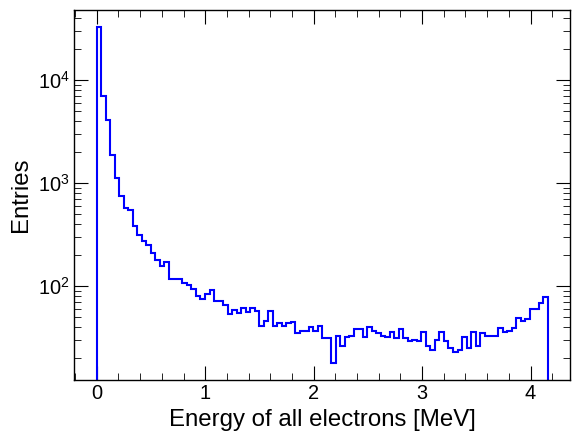

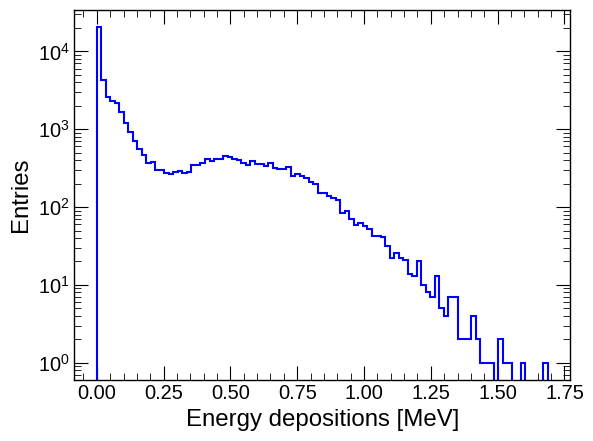

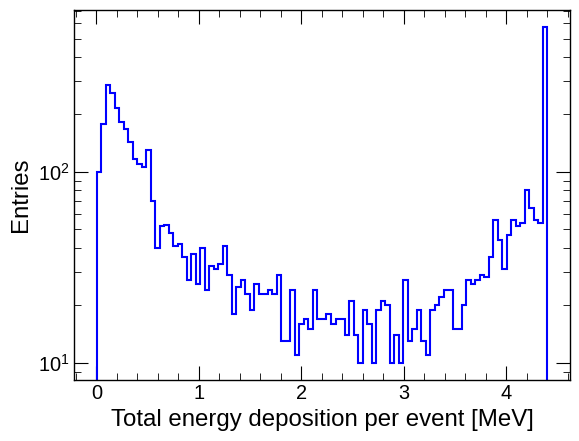

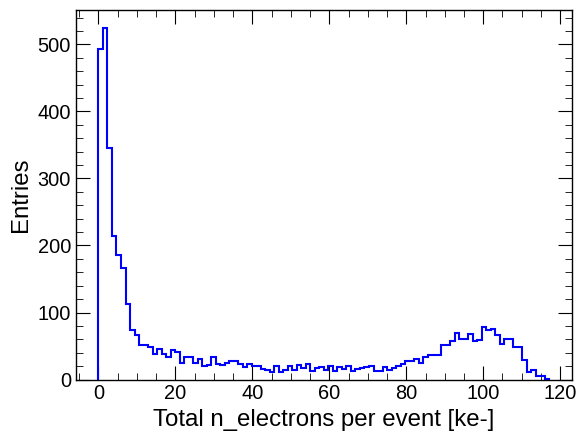

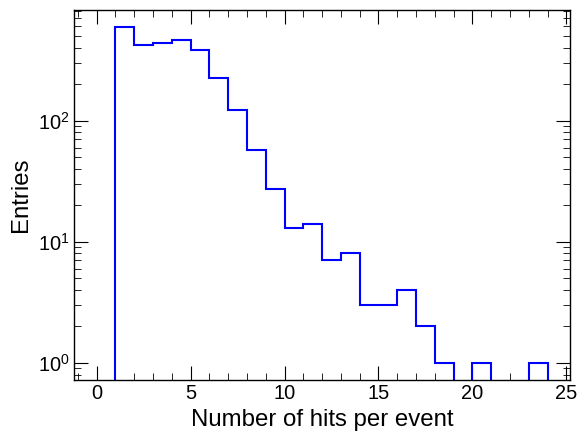

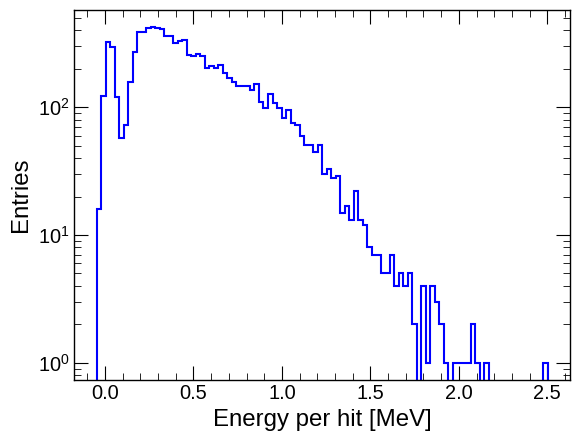

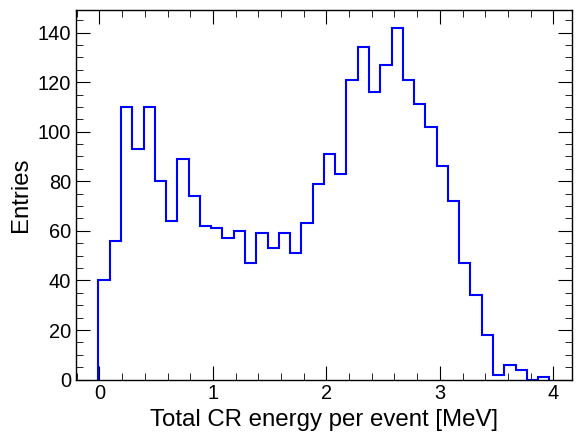

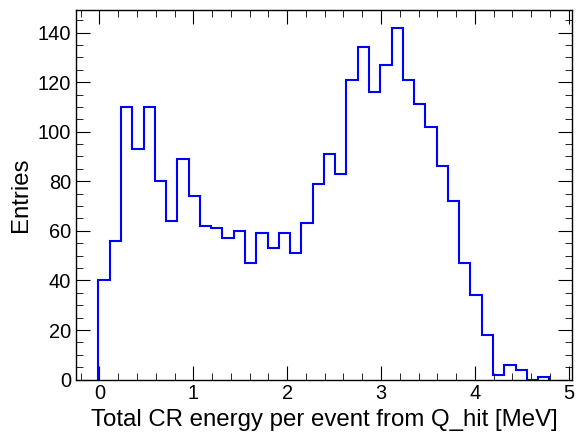

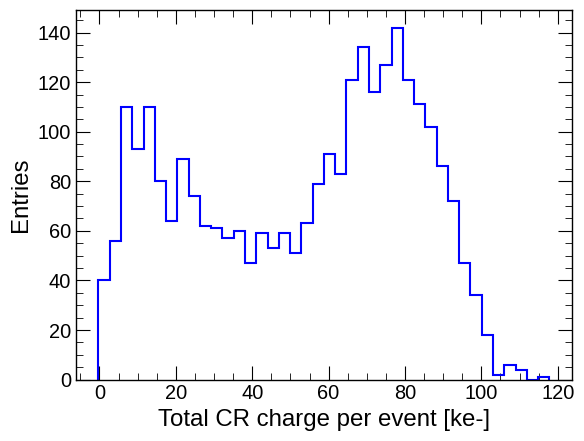

In [41]:
plot_hist(results['electron_energy'], bins=100, xlabel='Energy of all electrons [MeV]')
plot_hist(results['segment_dE'], bins=100, xlabel='Energy depositions [MeV]')
plot_hist(results['total_edep'], bins=100, xlabel='Total energy deposition per event [MeV]')
plot_hist(results['total_n_electrons']/1e3, bins=100, xlabel='Total n_electrons per event [ke-]',ylog=False)
plot_hist(results['hits_per_event'], bins=np.arange(0, max(results['hits_per_event'].max(initial=0) + 2, 20), 1), xlabel='Number of hits per event')
plot_hist(results['hit_energy'], bins=100, xlabel='Energy per hit [MeV]')
plot_hist(results['hit_total_energy'], bins=40, xlabel='Total CR energy per event [MeV]', ylog=False)
plot_hist(results['hit_total_energy_from_charge'], bins=40, xlabel='Total CR energy per event from Q_hit [MeV]', ylog=False)
plot_hist(results['hit_total_charge'], bins=40, xlabel='Total CR charge per event [ke-]', ylog=False)

In [42]:
# Optional: inspect a single file quickly if a distribution looks odd.
example_file = files[0]
with h5py.File(example_file, 'r') as h5_file:
    print(f"Example file: {example_file.name}")
    print(f"Top-level keys: {list(h5_file.keys())}")
    print(f"Trajectories keys: {h5_file['mc_truth/trajectories/data'].dtype.names}")
    print(f"Segments keys: {h5_file['mc_truth/segments/data'].dtype.names}")
    print(f"Prompt hit keys: {h5_file['charge/calib_prompt_hits/data'].dtype.names}")

Example file: 2x2_QGSP_BERT_HP_Gun_1777999902_0.FLOW.hdf5
Top-level keys: ['charge', 'combined', 'geometry_info', 'lar_info', 'light', 'mc_truth', 'run_info']
Trajectories keys: ('event_id', 'vertex_id', 'traj_id', 'file_traj_id', 'parent_id', 'primary', 'E_start', 'pxyz_start', 'xyz_start', 't_start', 'E_end', 'pxyz_end', 'xyz_end', 't_end', 'pdg_id', 'start_process', 'start_subprocess', 'end_process', 'end_subprocess', 'dist_travel')
Segments keys: ('event_id', 'vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE', 't', 'y', 'x', 'z', 'n_photons')
Prompt hit keys: ('id', 'x', 'y', 'z', 't_drift', 'ts_pps', 'io_group', 'io_channel', 'chip_id', 'channel_id', 'Q_raw', 'Q', 'E', 'is_disabled')
